## Section 1 — Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

In [2]:
# Paths
DATA_DIR = Path("../data")

df_lifestyle = pd.read_excel(DATA_DIR / "health_dataset1.xlsm")
df_activity = pd.read_excel(DATA_DIR / "health_dataset2.xlsm")

df_lifestyle.columns = df_lifestyle.columns.str.lower()
df_activity.columns = df_activity.columns.str.lower()

## Section 2 — Dataset Overview

#### Dataset 1

In [3]:
df_lifestyle.head()

,patient_number,blood_pressure_abnormality,level_of_hemoglobin,genetic_pedigree_coefficient,age,bmi,sex,pregnancy,smoking,salt_content_in_the_diet,alcohol_consumption_per_day,level_of_stress,chronic_kidney_disease,adrenal_and_thyroid_disorders
0,1,1,11.28,0.90,34,23,1,1.0,0,48071,NaN,2,1,1
1,2,0,9.75,0.23,54,33,1,NaN,0,25333,205.0,3,0,0
2,3,1,10.79,0.91,70,49,0,NaN,0,29465,67.0,2,1,0
3,4,0,11.00,0.43,71,50,0,NaN,0,7439,242.0,1,0,0
4,5,1,14.17,0.83,52,19,0,NaN,0,49644,397.0,2,0,0


In [4]:
print("Rows:", df_lifestyle.shape[0])
print("Columns:", df_lifestyle.shape[1])

Rows: 2000
Columns: 14


In [5]:
df_lifestyle.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 14 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   patient_number                 2000 non-null   int64  
 1   blood_pressure_abnormality     2000 non-null   int64  
 2   level_of_hemoglobin            2000 non-null   float64
 3   genetic_pedigree_coefficient   1908 non-null   float64
 4   age                            2000 non-null   int64  
 5   bmi                            2000 non-null   int64  
 6   sex                            2000 non-null   int64  
 7   pregnancy                      442 non-null    float64
 8   smoking                        2000 non-null   int64  
 9   salt_content_in_the_diet       2000 non-null   int64  
 10  alcohol_consumption_per_day    1758 non-null   float64
 11  level_of_stress                2000 non-null   int64  
 12  chronic_kidney_disease         2000 non-null   i

#### Dataset 2

In [6]:
df_activity.head()

,patient_number,day_number,physical_activity
0,1,1,23590.0
1,1,2,10411.0
2,1,3,7815.0
3,1,4,12366.0
4,1,5,NaN


In [7]:
print("Rows:", df_activity.shape[0])
print("Columns:", df_activity.shape[1])

Rows: 20000
Columns: 3


In [8]:
df_activity.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 3 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   patient_number     20000 non-null  int64  
 1   day_number         20000 non-null  int64  
 2   physical_activity  16159 non-null  float64
dtypes: float64(1), int64(2)
memory usage: 468.9 KB


## Section 3 — Data Quality Checks

#### Missing Values

In [10]:
df_lifestyle.isnull().sum()

patient_number                      0
blood_pressure_abnormality          0
level_of_hemoglobin                 0
genetic_pedigree_coefficient       92
age                                 0
bmi                                 0
sex                                 0
pregnancy                        1558
smoking                             0
salt_content_in_the_diet            0
alcohol_consumption_per_day       242
level_of_stress                     0
chronic_kidney_disease              0
adrenal_and_thyroid_disorders       0
dtype: int64

In [11]:
df_activity.isnull().sum()

patient_number          0
day_number              0
physical_activity    3841
dtype: int64

#### Duplicate Records

In [12]:
df_lifestyle.duplicated().sum()

0

In [15]:
df_lifestyle['patient_number'].nunique()

2000

In [13]:
df_activity.duplicated().sum()

0

In [16]:
df_activity['patient_number'].nunique()

2000

In [17]:
df_activity.groupby("patient_number").size().describe()

count    2000.0
mean       10.0
std         0.0
min        10.0
25%        10.0
50%        10.0
75%        10.0
max        10.0
dtype: float64

## Section 4 — Statistical Summary

In [19]:
df_lifestyle.describe()

,patient_number,blood_pressure_abnormality,level_of_hemoglobin,genetic_pedigree_coefficient,age,bmi,sex,pregnancy,smoking,salt_content_in_the_diet,alcohol_consumption_per_day,level_of_stress,chronic_kidney_disease,adrenal_and_thyroid_disorders
count,2000.000000,2000.000000,2000.000000,1908.000000,2000.000000,2000.000000,2000.000000,442.000000,2000.000000,2000.000000,1758.000000,2000.000000,2000.000000,2000.000000
mean,1000.500000,0.493500,11.710035,0.494817,46.558500,30.081500,0.496000,0.450226,0.509500,24926.097000,251.008532,2.012500,0.356500,0.298000
std,577.494589,0.500083,2.186701,0.291736,17.107832,11.761208,0.500109,0.498080,0.500035,14211.692586,143.651884,0.823822,0.479085,0.457494
min,1.000000,0.000000,8.100000,0.000000,18.000000,10.000000,0.000000,0.000000,0.000000,22.000000,0.000000,1.000000,0.000000,0.000000
25%,500.750000,0.000000,10.147500,0.240000,32.000000,20.000000,0.000000,0.000000,0.000000,13151.750000,126.250000,1.000000,0.000000,0.000000
50%,1000.500000,0.000000,11.330000,0.490000,46.000000,30.000000,0.000000,0.000000,1.000000,25046.500000,250.000000,2.000000,0.000000,0.000000
75%,1500.250000,1.000000,12.945000,0.740000,62.000000,40.000000,1.000000,1.000000,1.000000,36839.750000,377.750000,3.000000,1.000000,1.000000
max,2000.000000,1.000000,17.560000,1.000000,75.000000,50.000000,1.000000,1.000000,1.000000,49976.000000,499.000000,3.000000,1.000000,1.000000


In [20]:
df_activity.describe()

,patient_number,day_number,physical_activity
count,20000.000000,20000.000000,16159.000000
mean,1000.500000,5.500000,25353.499969
std,577.364631,2.872353,9885.999907
min,1.000000,1.000000,628.000000
25%,500.750000,3.000000,18564.000000
50%,1000.500000,5.500000,25488.000000
75%,1500.250000,8.000000,32080.000000
max,2000.000000,10.000000,49980.000000


## Section 5 — Distribution Analysis

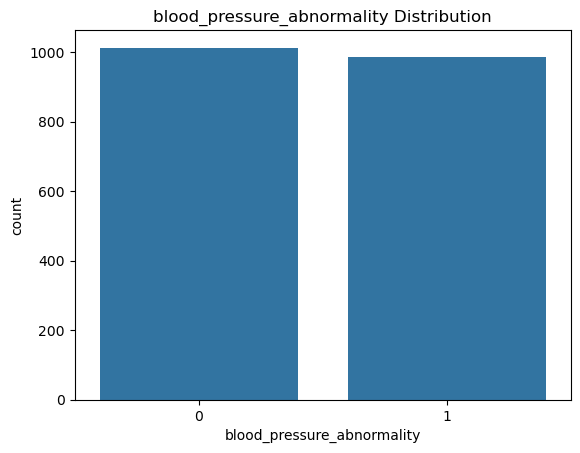

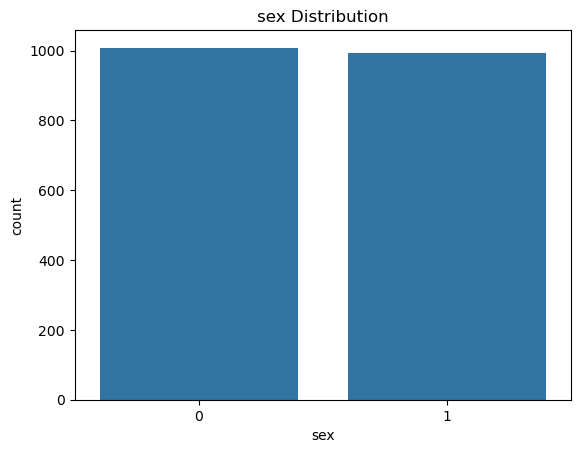

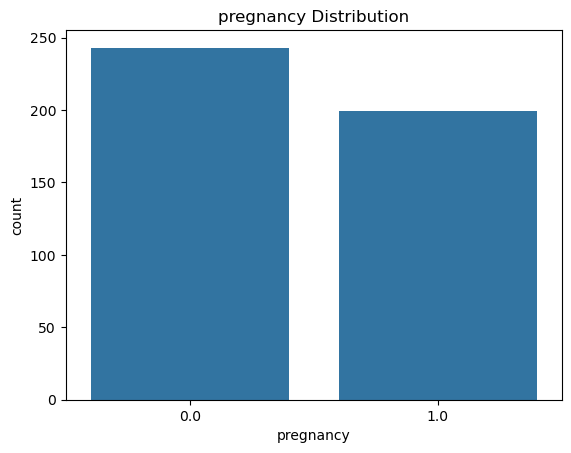

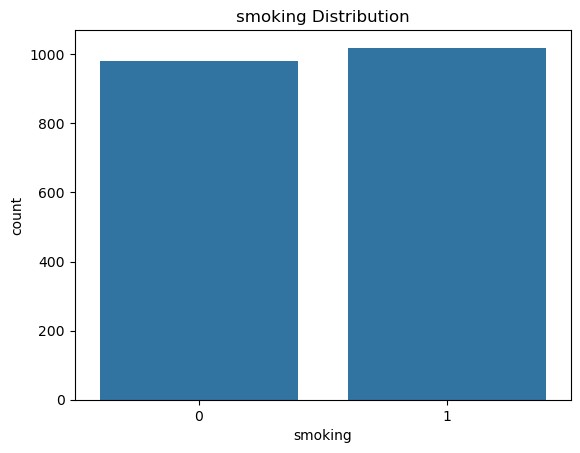

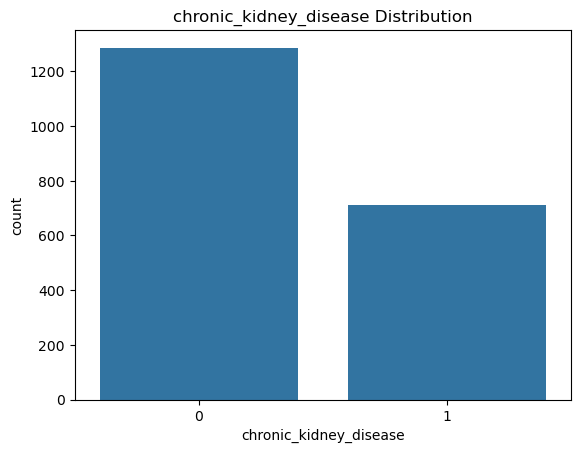

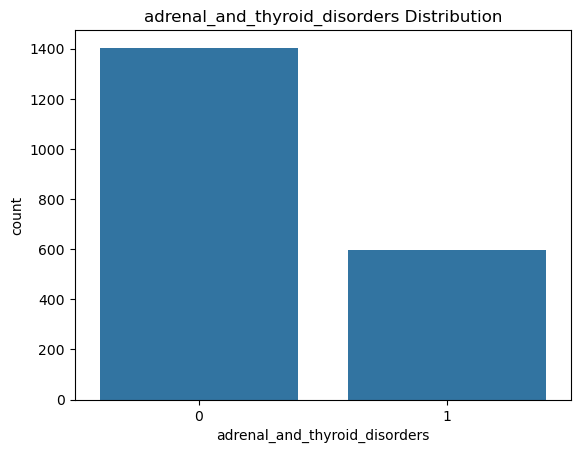

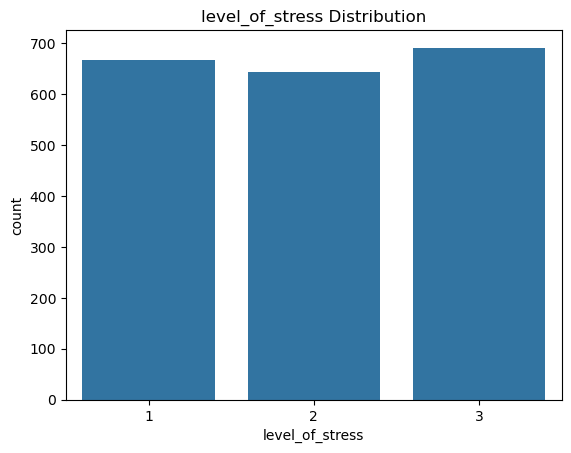

In [27]:
columns = ['blood_pressure_abnormality',
           'sex',
           'pregnancy',
           'smoking',
           'chronic_kidney_disease',
           'adrenal_and_thyroid_disorders',
           'level_of_stress']
for col in columns:
    sns.countplot(x=col, data=df_lifestyle)
    plt.title(col+" Distribution")
    plt.show()

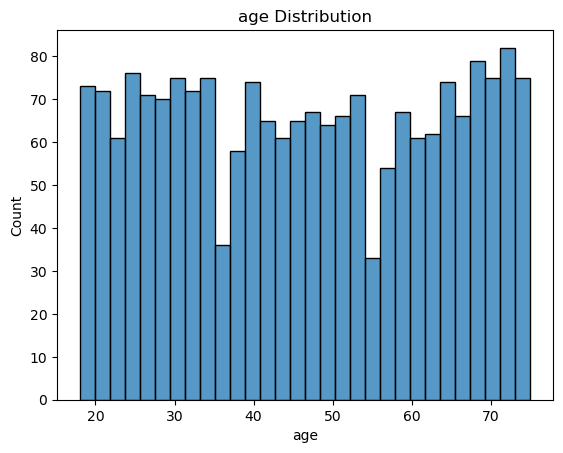

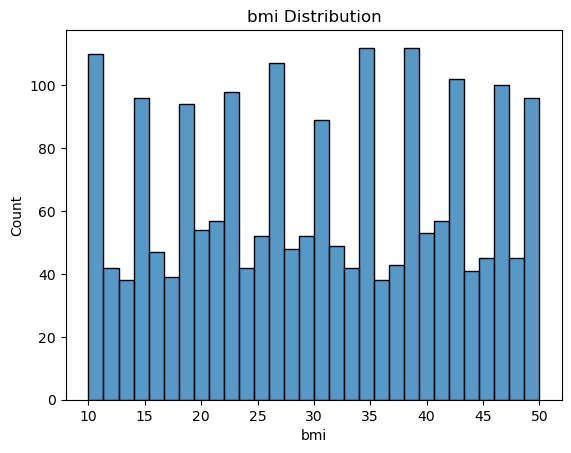

In [23]:
columns = ['age','bmi']
for column in columns:
    sns.histplot(df_lifestyle[column], bins=30)
    plt.title(column+" Distribution")
    plt.show()

## Section 7 — Correlation Analysis

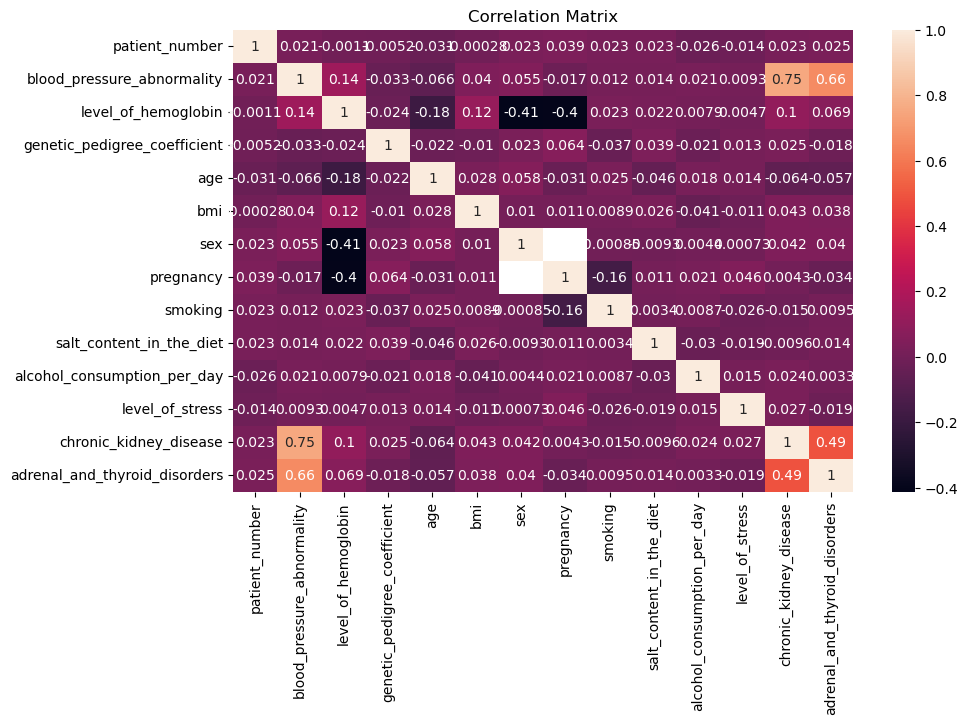

In [29]:
corr = df_lifestyle.corr(numeric_only=True)

plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True)
plt.title("Correlation Matrix")
plt.show()

## Section 8 — Physical Activity Analysis

<Axes: xlabel='physical_activity', ylabel='Count'>

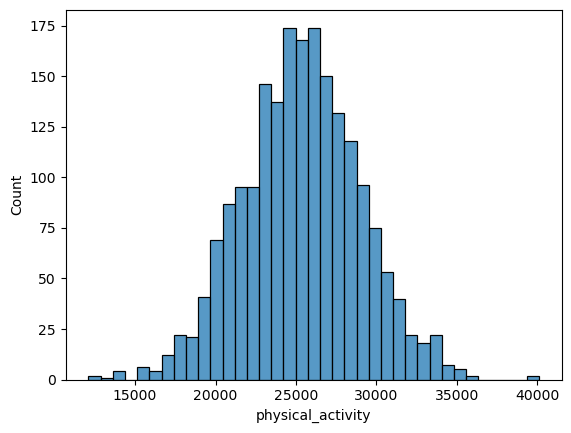

In [32]:
# average steps per patient
activity_summary = df_activity.groupby("patient_number")["physical_activity"].mean()
sns.histplot(activity_summary)

## Section 9 — Join Validation

In [33]:
merged = df_lifestyle.merge(
    df_activity,
    on="patient_number",
    how="inner"
)

In [34]:
merged.shape

(20000, 16)

## Section 10 — Key Insights

1.) Total informatiom available for 2000 patients in the dataset 1 and dataset 2 have 10 records for each patient which is there physical activity for the 10 days.

2.) Missing values are present in follwing fields: genetic_pedigree_coefficient, pregnancy,alcohol_consumption_per_day, physical_activity - We will treat them as missing and keep them as NaN, so that analytics agent can treat them as not captured and not use them in any analysis. (WE could have also used imputation techniques to impute them but skipping here).

3.) No duplicate records present.

4.) we have almost equal representation of people on basic of there sex, and age group is also well scattered between 18 to 75.

5.) blood pressure abnormality, smoking and  level of stress have almost same distribution levels.

6.) Chronic kidney disease prevalence is 36% and adrenal_and_thyroid_disorders prevelance is 30%

7.) Physical activity distribution varies significantly across patients.

8.) high positive correlation between blood pressure abnormality and CKD and adrenal or thyroid disorder.
